In [1]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import math

import sklearn
from sklearn.model_selection import train_test_split

import hamiltorch
from hamiltorch.util import flatten, unflatten

print("Library Versions:")
print('numpy:',np.__version__)
print('pandas:',pd.__version__)
print('torch:',torch.__version__)
print('sklearn:',sklearn.__version__)
print(torch.cuda.is_available())          # Should print: True
print(torch.cuda.get_device_name(0))      # Should print: your GPU model


Library Versions:
numpy: 1.23.5
pandas: 2.3.2
torch: 2.8.0+cu128
sklearn: 1.7.2
True
NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [2]:
# ──────────────────────────────────────────────────────────────────────────────
# 0) Check for CUDA
# ──────────────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:

# Read the dataset
rov = pd.read_csv(
    "/home/andrew/fossen_ml_pipeline/defender_parameter_estimator/csv_files/N_Data/Tank_data/defender_data_n_run_1_only_mocap_data_savgol.csv",
    sep="\t"
)

# Drop the first 3 rows
rov = rov.iloc[3:].reset_index(drop=True)

# -------------------------------
# Columns to require (no NaNs)
# -------------------------------
signal_cols = [
    "u_dot","v_dot","w_dot","p_dot","q_dot","r_dot",
    "u","v","w","p","q","r",
    "x","y","z","phi","theta","psi",
    "X","Y","Z","K","M","N",
]
signal_cols = [c for c in signal_cols if c in rov.columns]

# If you want to ALSO require the valid flags (optional)
flag_cols = [c for c in ["pose_valid", "twist_valid", "wrench_valid"] if c in rov.columns]
age_cols  = [c for c in ["pose_age", "twist_age", "wrench_age"] if c in rov.columns]

# Make flags ints (in case they come in as floats)
for c in flag_cols:
    rov[c] = rov[c].fillna(0).astype(int)

# -------------------------------
# 1) DROP ROWS WITH NaNs
# -------------------------------
before = len(rov)
rov = rov.dropna(subset=signal_cols).reset_index(drop=True)
after = len(rov)
print(f"Dropped {before - after} rows due to NaNs in required signal columns.")

# (Optional) if you want to be extra strict and only keep rows where mocap pose/twist are valid:
# if "twist_valid" in rov.columns:
#     rov = rov[rov["twist_valid"] == 1].reset_index(drop=True)
# if "pose_valid" in rov.columns:
#     rov = rov[rov["pose_valid"] == 1].reset_index(drop=True)

# -------------------------------
# 2) Epsilon-zero + rounding
# -------------------------------
epsilon = 1e-4

arr = rov[signal_cols].to_numpy(dtype=float)

# No NaNs should remain, but keep this safe anyway
finite = np.isfinite(arr)
arr[finite & (np.abs(arr) < epsilon)] = 0.0
arr[finite] = np.round(arr[finite], 5)

rov[signal_cols] = arr

# Keep ages tidy (optional)
for c in age_cols:
    rov[c] = rov[c].astype(float).round(6)

# Print cleaned result
print("Cleaned shape:", rov.shape)
print("First few rows:\n", rov.head())

# Sanity check: should be 0 now
print("\nNaNs per column (top 10):")
print(rov.isna().sum().sort_values(ascending=False).head(10))


Dropped 0 rows due to NaNs in required signal columns.
Cleaned shape: (40117, 25)
First few rows:
            time    u_dot    v_dot    w_dot    p_dot    q_dot    r_dot  \
0  1.764789e+09  0.06807 -0.30849 -0.35826  0.75279  0.21283  0.88716   
1  1.764789e+09  0.06730 -0.30373 -0.35779  0.78390  0.20460  0.85596   
2  1.764789e+09  0.06842 -0.30732 -0.36728  0.83836  0.20199  0.84780   
3  1.764789e+09  0.09513 -0.42502 -0.51543  1.22486  0.27236  1.14640   
4  1.764789e+09  0.06130 -0.27223 -0.33507  0.82844  0.16997  0.71700   

         u        v        w  ...        z      phi    theta      psi    X  \
0 -0.13050  0.08562  0.13811  ... -1.24941  0.01744 -0.09942 -2.44378  0.0   
1 -0.12945  0.08088  0.13257  ... -1.24808  0.01431 -0.09976 -2.44622  0.0   
2 -0.12844  0.07634  0.12718  ... -1.24562  0.00770 -0.09948 -2.45075  0.0   
3 -0.12747  0.07200  0.12195  ... -1.24438  0.00535 -0.09856 -2.45278  0.0   
4 -0.12654  0.06784  0.11687  ... -1.24329  0.00170 -0.09882 -2.45501  0

In [20]:

#### ====== MASTER CSV CLEANER SCRIPT ======== ####


rov_train_np, rov_test_np = shape_defender_data(
    rov,
    drop_dvl=True,
    drop_all_nans=True,
    active_dofs=["Z"]     # or "Z" -> but use ["Z"] to match list-based logic
)

def shape_defender_data(
    rov,
    drop_dvl=True,
    drop_all_nans=True,
    active_dofs="Z",    # e.g., ["X", "Y", "Z"] or ["Z"]
    test_size=0.25,
    random_state=42
):
    """
    Shapes Defender CSV data for ML training.

    Parameters
    ----------
    rov : DataFrame
        Cleaned raw dataframe.
    drop_dvl : bool
        Drop rows where DVL (u, v, w) is NaN.
    drop_all_nans : bool
        Drop rows with NaNs in ANY ν, ν̇, or η variable.
    active_dofs : list[str]
        Optional list of DOFs to keep non-zero.
        Examples: ["X"], ["Z"], ["X", "Z"], etc.
    """

    # ----------------------------------------------------------
    # 1. Drop DVL-missing rows
    # ----------------------------------------------------------
    if drop_dvl:
        required_dvl_cols = ["u", "v", "w"]
        rov = rov.dropna(subset=required_dvl_cols)
        print("After DVL drop:", rov.shape)

    # ----------------------------------------------------------
    # 2. Drop rows where ANY ν̇, ν, η contains NaNs
    # ----------------------------------------------------------
    if drop_all_nans:
        # Columns containing the physical state data
        state_cols = [col for col in rov.columns if col not in ["time"]]

        rov = rov.dropna(subset=state_cols)
        print("After full-state NaN drop:", rov.shape)

    # ----------------------------------------------------------
    # 3. Zero out non-active DOFs
    # ----------------------------------------------------------
    if active_dofs is not None:
        # DOF → column mapping
        dof_map = {
            "X": ["u", "u_dot"],
            "Y": ["v", "v_dot"],
            "Z": ["w", "w_dot"],
            "K": ["p", "p_dot"],
            "M": ["q", "q_dot"],
            "N": ["r", "r_dot"],
        }

        # all possible DOFs
        all_dofs = list(dof_map.keys())

        # determine DOFs to zero out
        inactive_dofs = [d for d in all_dofs if d not in active_dofs]

        for d in inactive_dofs:
            for col in dof_map[d]:
                if col in rov.columns:
                    rov[col] = 0.0

        print(f"Zeroed DOFs (inactive): {inactive_dofs}")

    # ----------------------------------------------------------
    # 4. Drop time & convert to NumPy
    # ----------------------------------------------------------
    if "time" in rov.columns:
        rov_numeric = rov.drop(columns=["time"])
    else:
        rov_numeric = rov.copy()

    # Convert to numpy
    rov_np = rov_numeric.to_numpy(dtype=float)

    # ----------------------------------------------------------
    # 5. Train/test split
    # ----------------------------------------------------------
    rov_train_np, rov_test_np = train_test_split(
        rov_np, test_size=test_size, random_state=random_state
    )

    return rov_train_np, rov_test_np


After DVL drop: (12392, 25)
After full-state NaN drop: (12392, 25)
Zeroed DOFs (inactive): ['X', 'Y', 'K', 'M', 'N']


In [4]:
# === Clean and split ROV dataset === REAL WORLD DEFENDER DATA PARSING

# Drop non-numeric / metadata columns
rov_numerics = rov.drop(columns=["time"])


# Convert to NumPy (force float dtype)
rov_np = rov_numerics.to_numpy(dtype=float)

# Train/test split
rov_train_np, rov_test_np = train_test_split(rov_np, test_size=0.25, random_state=42)


In [5]:
# === Full input data ===
x_train_np = rov_train_np[:, :18]
y_train_np = rov_train_np[:, 18:24]

x_test_np = rov_test_np[:, :18]
y_test_np = rov_test_np[:, 18:24]

# === Split x into [nu_dot, nu, eta] ===
nu_dot_train = x_train_np[:, 0:6]
nu_train     = x_train_np[:, 6:12]
eta_train    = x_train_np[:, 12:18]

nu_dot_test = x_test_np[:, 0:6]
nu_test     = x_test_np[:, 6:12]
eta_test    = x_test_np[:, 12:18]


In [6]:
# Convert to PyTorch tensors
nu_dot_train = torch.tensor(nu_dot_train, dtype=torch.float32)
nu_train     = torch.tensor(nu_train,     dtype=torch.float32)
eta_train    = torch.tensor(eta_train,    dtype=torch.float32)
y_train      = torch.tensor(y_train_np,   dtype=torch.float32)

nu_dot_test = torch.tensor(nu_dot_test, dtype=torch.float32)
nu_test     = torch.tensor(nu_test,     dtype=torch.float32)
eta_test    = torch.tensor(eta_test,    dtype=torch.float32)
y_test      = torch.tensor(y_test_np,   dtype=torch.float32)


## CUDA THE DATA 

In [7]:
nu_dot_train = nu_dot_train.to(device)
nu_train     = nu_train.to(device)
eta_train    = eta_train.to(device)
y_train      = y_train.to(device)

nu_dot_test  = nu_dot_test.to(device)
nu_test      = nu_test.to(device)
eta_test     = eta_test.to(device)
y_test       = y_test.to(device)


In [8]:
class ROVDynamicsModel(nn.Module):
    """
    Your existing dynamics node, regenerated with component flags added.

    Flags:
      - use_Crb: include rigid-body Coriolis/centripetal matrix C_RB(nu)
      - use_Ca : include added-mass Coriolis matrix C_A(nu)  (Munk-moment source)
      - use_D  : include damping D(nu)
      - use_g  : include restoring forces g(eta)

    Default: use_Ca=False (stable if you don't model off-diagonal damping).
    """

    def __init__(
        self,
        use_Crb: bool = True,
        use_Ca: bool = True,
        use_D: bool = True,
        use_g: bool = True,
        m_val: float = 23.89,

        learn_inertia: bool = False,
        Ixx_cad: float = 0.393,
        Iyy_cad: float = 1.302,
        Izz_cad: float = 1.429,
    ):

        super().__init__()

        # -----------------------------
        # Component toggles
        # -----------------------------
        self.use_Crb = use_Crb
        self.use_Ca  = use_Ca
        self.use_D   = use_D
        self.use_g   = use_g

        # === (1) Added-Mass Coefficients (must be negative) ===
        self.X_dot_u = nn.Parameter(torch.tensor(-30.579))
        self.Y_dot_v = nn.Parameter(torch.tensor(-30.938))
        self.Z_dot_w = nn.Parameter(torch.tensor(-56.142))
        self.K_dot_p = nn.Parameter(torch.tensor(-0.282))
        self.M_dot_q = nn.Parameter(torch.tensor(-0.599))
        self.N_dot_r = nn.Parameter(torch.tensor(-0.523))

        # === (2) Rigid-Body Moments of Inertia ===
        # --- Mass (fixed) ---
        self.m_val = float(m_val)

        # --- Inertias: learnable or CAD-fixed ---
        self.learn_inertia = bool(learn_inertia)

        self.register_buffer("Ixx_cad", torch.tensor(float(Ixx_cad), dtype=torch.float32))
        self.register_buffer("Iyy_cad", torch.tensor(float(Iyy_cad), dtype=torch.float32))
        self.register_buffer("Izz_cad", torch.tensor(float(Izz_cad), dtype=torch.float32))

        if self.learn_inertia:
            self.I_xx = nn.Parameter(self.Ixx_cad.clone())
            self.I_yy = nn.Parameter(self.Iyy_cad.clone())
            self.I_zz = nn.Parameter(self.Izz_cad.clone())
        else:
            self.I_xx = None
            self.I_yy = None
            self.I_zz = None



        # === (3) Center of Gravity Offsets ===
        self.x_g = nn.Parameter(torch.tensor(0.0))
        self.y_g = nn.Parameter(torch.tensor(0.0))
        self.z_g = nn.Parameter(torch.tensor(0.0))

        # === (4) Linear Damping Coefficients (must be negative) ===
        self.X_u = nn.Parameter(torch.tensor(-2.00))
        self.Y_v = nn.Parameter(torch.tensor(-2.00))
        self.Z_w = nn.Parameter(torch.tensor(-2.00))
        self.K_p = nn.Parameter(torch.tensor(-1.00))
        self.M_q = nn.Parameter(torch.tensor(-1.00))
        self.N_r = nn.Parameter(torch.tensor(-1.00))

        # === (5) Quadratic Damping Coefficients (must be negative) ===
        self.X_uu = nn.Parameter(torch.tensor(-28.875))
        self.Y_vv = nn.Parameter(torch.tensor(-95.716))
        self.Z_ww = nn.Parameter(torch.tensor(-106.526))
        self.K_pp = nn.Parameter(torch.tensor(-0.592))
        self.M_qq = nn.Parameter(torch.tensor(-1.811))
        self.N_rr = nn.Parameter(torch.tensor(-4.734))

        # === (6) Restoring Force / Buoyancy Parameters ===
        self.B   = nn.Parameter(torch.tensor(234.36))  # ~169 N
        self.z_b = nn.Parameter(torch.tensor(-0.02))

        # === (7) Constant Physical Mass (non-learnable) ===


        # Debug storage (optional)
        self.Crb = None
        self.Ca  = None
        self.C   = None
        self.D   = None


    def _get_inertias(self, device, dtype=torch.float32):
        if self.learn_inertia:
            Ixx = self.I_xx.to(device=device, dtype=dtype)
            Iyy = self.I_yy.to(device=device, dtype=dtype)
            Izz = self.I_zz.to(device=device, dtype=dtype)
        else:
            Ixx = self.Ixx_cad.to(device=device, dtype=dtype)
            Iyy = self.Iyy_cad.to(device=device, dtype=dtype)
            Izz = self.Izz_cad.to(device=device, dtype=dtype)
        return Ixx, Iyy, Izz


    # ---------------------------------------------------------------------
    # MASS MATRIX
    # ---------------------------------------------------------------------
    def build_mass_matrix(self):
        """
        Build the full 6×6 mass matrix M = M_RB + M_A (Fossen Eq. 3.49).
        Uses NED convention (z down).
        Fully differentiable (no torch.tensor() breaks).
        """
        Ma = -1.0 * torch.diag(torch.stack([
            self.X_dot_u, self.Y_dot_v, self.Z_dot_w,
            self.K_dot_p, self.M_dot_q, self.N_dot_r
        ]))

        m  = torch.as_tensor(self.m_val, dtype=torch.float32, device=Ma.device)
        xg = self.x_g
        yg = self.y_g
        zg = self.z_g

        Ixx, Iyy, Izz = self._get_inertias(device=Ma.device, dtype=torch.float32)

        Mrb = torch.zeros((6, 6), dtype=torch.float32, device=Ma.device)

        Mrb[0, 0] = m
        Mrb[1, 1] = m
        Mrb[2, 2] = m
        Mrb[0, 4] =  m * zg
        Mrb[0, 5] = -m * yg
        Mrb[1, 3] = -m * zg
        Mrb[1, 5] =  m * xg
        Mrb[2, 3] =  m * yg
        Mrb[2, 4] = -m * xg
        Mrb[3, 1] = -m * zg
        Mrb[3, 2] =  m * yg
        Mrb[3, 3] = Ixx
        Mrb[4, 0] =  m * zg
        Mrb[4, 2] = -m * xg
        Mrb[4, 4] = Iyy
        Mrb[5, 0] = -m * yg
        Mrb[5, 1] =  m * xg
        Mrb[5, 5] = Izz

        return Mrb + Ma

    # ---------------------------------------------------------------------
    # CORIOLIS (Crb + optional Ca)
    # ---------------------------------------------------------------------
    def build_coriolis(self, nu):
        """
        Build C_total(nu) = (use_Crb)*C_RB(nu) + (use_Ca)*C_A(nu)

        nu: (batch,6)
        returns: (batch,6,6)
        """
        u, v, w, p, q, r = [nu[:, i] for i in range(6)]
        B = nu.shape[0]

        m = torch.as_tensor(self.m_val, dtype=torch.float32, device=nu.device)
        Ixx, Iyy, Izz = self._get_inertias(device=nu.device, dtype=torch.float32)

        xg = self.x_g
        yg = self.y_g
        zg = self.z_g

        # === Build C_RB (rigid-body) ===
        Crb = torch.zeros((B, 6, 6), dtype=torch.float32, device=nu.device)

        Crb[:, 0, 0] = 0.0
        Crb[:, 0, 1] = -m * r
        Crb[:, 0, 2] =  m * q
        Crb[:, 0, 3] =  m * (q * yg + r * zg)
        Crb[:, 0, 4] = -m * (q * xg)
        Crb[:, 0, 5] = -m * (r * xg)

        Crb[:, 1, 0] =  m * r
        Crb[:, 1, 1] = 0.0
        Crb[:, 1, 2] = -m * p
        Crb[:, 1, 3] = -m * (p * yg)
        Crb[:, 1, 4] =  m * (p * xg + r * zg)
        Crb[:, 1, 5] = -m * (r * yg)

        Crb[:, 2, 0] = -m * q
        Crb[:, 2, 1] =  m * p
        Crb[:, 2, 2] = 0.0
        Crb[:, 2, 3] = -m * (p * zg)
        Crb[:, 2, 4] = -m * (q * zg)
        Crb[:, 2, 5] =  m * (p * xg + q * yg)

        Crb[:, 3, 0] = -m * (q * yg + r * zg)
        Crb[:, 3, 1] =  m * (p * yg)
        Crb[:, 3, 2] =  m * (p * zg)
        Crb[:, 3, 3] = 0.0
        Crb[:, 3, 4] =  Izz * r
        Crb[:, 3, 5] = -Iyy * q

        Crb[:, 4, 0] =  m * (q * xg)
        Crb[:, 4, 1] = -m * (p * xg + r * zg)
        Crb[:, 4, 2] =  m * (q * zg)
        Crb[:, 4, 3] = -Izz * r
        Crb[:, 4, 4] = 0.0
        Crb[:, 4, 5] =  Ixx * p

        Crb[:, 5, 0] =  m * (r * xg)
        Crb[:, 5, 1] =  m * (r * yg)
        Crb[:, 5, 2] = -m * (p * xg + q * yg)
        Crb[:, 5, 3] =  Iyy * q
        Crb[:, 5, 4] = -Ixx * p
        Crb[:, 5, 5] = 0.0

        # === Build C_A (added-mass) ===
        Ca = torch.zeros_like(Crb)
        if self.use_Ca:
            a1 = self.X_dot_u * u
            a2 = self.Y_dot_v * v
            a3 = self.Z_dot_w * w
            b1 = self.K_dot_p * p
            b2 = self.M_dot_q * q
            b3 = self.N_dot_r * r

            Ca[:, 0, 4] = -a3
            Ca[:, 0, 5] =  a2
            Ca[:, 1, 3] =  a3
            Ca[:, 1, 5] = -a1
            Ca[:, 2, 3] = -a2
            Ca[:, 2, 4] =  a1

            Ca[:, 3, 1] = -a3
            Ca[:, 3, 2] =  a2
            Ca[:, 3, 4] = -b3
            Ca[:, 3, 5] =  b2

            Ca[:, 4, 0] =  a3
            Ca[:, 4, 2] = -a1
            Ca[:, 4, 3] =  b3
            Ca[:, 4, 5] = -b1

            Ca[:, 5, 0] = -a2
            Ca[:, 5, 1] =  a1
            Ca[:, 5, 3] = -b2
            Ca[:, 5, 4] =  b1

        # === Total Coriolis with flags ===
        C_total = torch.zeros_like(Crb)
        if self.use_Crb:
            C_total = C_total + Crb
        if self.use_Ca:
            C_total = C_total + Ca

        self.Crb = Crb
        self.Ca  = Ca
        self.C   = C_total
        return C_total

    # ---------------------------------------------------------------------
    # DAMPING
    # ---------------------------------------------------------------------
    def build_damping(self, nu):
        """
        Damping matrix D(ν) with negative coefficients AND a leading -1.

            diag_entries = lin + quad*|nu|
            D = -diag(diag_entries)

        Coefficients expected to be NEGATIVE values.
        """
        lin_params = torch.stack([
            self.X_u, self.Y_v, self.Z_w,
            self.K_p, self.M_q, self.N_r
        ])

        quad_params = torch.stack([
            self.X_uu, self.Y_vv, self.Z_ww,
            self.K_pp, self.M_qq, self.N_rr
        ])

        diag_entries = lin_params.unsqueeze(0) + quad_params.unsqueeze(0) * torch.abs(nu)
        D = -1.0 * torch.diag_embed(diag_entries)

        self.D = D
        return D

    # ---------------------------------------------------------------------
    # RESTORING FORCE
    # ---------------------------------------------------------------------
    def build_restoring_force(self, eta):
        """
        Fossen Eq. (3.77) restoring forces in NED.
        eta: (batch,6) [x,y,z,phi,theta,psi]
        """
        phi = eta[:, 3]
        theta = eta[:, 4]

        g = 9.8
        m = torch.as_tensor(self.m_val, dtype=torch.float32, device=eta.device)
        W = m * g
        B = self.B.to(dtype=torch.float32, device=eta.device)

        x_G, y_G, z_G = self.x_g, self.y_g, self.z_g
        x_B = torch.zeros(1, device=eta.device)
        y_B = torch.zeros(1, device=eta.device)
        z_B = self.z_b.to(dtype=torch.float32, device=eta.device)

        WB    = W - B
        xW_xB = x_G * W - x_B * B
        yW_yB = y_G * W - y_B * B
        zW_zB = z_G * W - z_B * B

        tau_g = torch.stack([
            WB * torch.sin(theta),
            -WB * torch.cos(theta) * torch.sin(phi),
            -WB * torch.cos(theta) * torch.cos(phi),
            -yW_yB * torch.cos(theta) * torch.cos(phi) + zW_zB * torch.cos(theta) * torch.sin(phi),
            zW_zB * torch.sin(theta) + xW_xB * torch.cos(theta) * torch.cos(phi),
            -xW_xB * torch.cos(theta) * torch.sin(phi) - yW_yB * torch.sin(theta)
        ], dim=1)

        return tau_g

    # ---------------------------------------------------------------------
    # FORWARD
    # ---------------------------------------------------------------------
    def forward(self, nu_dot, nu, eta):
        # === Mass force: M * nu_dot ===
        M = self.build_mass_matrix()                  # (6,6)
        tau_M = torch.matmul(nu_dot, M.T)             # (batch,6)

        # === Coriolis force: C(nu) * nu ===
        C = self.build_coriolis(nu)                   # (batch,6,6)
        tau_C = torch.einsum("bij,bj->bi", C, nu)     # (batch,6)

        # === Damping force ===
        if self.use_D:
            D = self.build_damping(nu)                # (batch,6,6)
            tau_D = torch.einsum("bij,bj->bi", D, nu)
        else:
            tau_D = torch.zeros_like(tau_M)

        # === Restoring force ===
        if self.use_g:
            tau_g = self.build_restoring_force(eta)   # (batch,6)
        else:
            tau_g = torch.zeros_like(tau_M)

        # === Total wrench ===
        tau = tau_M + tau_C + tau_D + tau_g
        return tau


In [60]:
# MLE-centered prior means (from your Table A.10)
prior_means_mle = {
    # Rigid-body
    "m":   torch.tensor(23.89),
    "I_xx": torch.tensor(0.50),
    "I_yy": torch.tensor(1.76),
    "I_zz": torch.tensor(2.13),
    "x_g": torch.tensor(0.0),
    "y_g": torch.tensor(0.0),
    "z_g": torch.tensor(0.0),

    # Hydrostatics
    "B":   torch.tensor(236.00),
    "z_b": torch.tensor(-0.03),

    # Added mass (diagonal)
    "X_dot_u": torch.tensor(-33.61),
    "Y_dot_v": torch.tensor(-31.56),
    "Z_dot_w": torch.tensor(-79.58),
    "K_dot_p": torch.tensor(-0.10),
    "M_dot_q": torch.tensor(-0.46),
    "N_dot_r": torch.tensor(-0.70),

    # Linear damping (diagonal)
    "X_u": torch.tensor(-16.49),
    "Y_v": torch.tensor(-34.05),
    "Z_w": torch.tensor(-35.66),
    "K_p": torch.tensor(-1.24),
    "M_q": torch.tensor(-2.08),
    "N_r": torch.tensor(-2.89),

    # Quadratic damping (diagonal)
    "X_uu": torch.tensor(-42.49),
    "Y_vv": torch.tensor(-108.74),
    "Z_ww": torch.tensor(-128.31),
    "K_pp": torch.tensor(-0.08),
    "M_qq": torch.tensor(-1.61),
    "N_rr": torch.tensor(-2.69),
}


In [9]:
#MAP CENTERED VALUES

prior_means_map = {
    "X_dot_u": torch.tensor(-30.579),
    "Y_dot_v": torch.tensor(-30.938),
    "Z_dot_w": torch.tensor(-56.142),
    "K_dot_p": torch.tensor(-0.282),
    "M_dot_q": torch.tensor(-0.599),
    "N_dot_r": torch.tensor(-0.523),


    "I_xx": torch.tensor(0.393), #from CAD
    "I_yy": torch.tensor(1.302), #from CAD
    "I_zz": torch.tensor(1.429), #from CAD

    "x_g": torch.tensor(0.0),
    "y_g": torch.tensor(0.0),
    "z_g": torch.tensor(0.0),

    "X_u": torch.tensor(-0.00),
    "Y_v": torch.tensor(-0.00),
    "Z_w": torch.tensor(-0.00),
    "K_p": torch.tensor(-0.00),
    "M_q": torch.tensor(-0.00),
    "N_r": torch.tensor(-0.00),

    "X_uu": torch.tensor(-28.875),
    "Y_vv": torch.tensor(-95.716),
    "Z_ww": torch.tensor(-106.526),
    "K_pp": torch.tensor(-0.592),
    "M_qq": torch.tensor(-1.811),
    "N_rr": torch.tensor(-4.734),

    "B": torch.tensor(240.00),
    "z_b": torch.tensor(-0.02)
}


In [255]:
# SIM TRUTH-centered prior means (HoloOcean ground truth)
prior_means_sim_truth = {
    # Rigid-body
    "m":   torch.tensor(17.2),
    "I_xx": torch.tensor(1.0),
    "I_yy": torch.tensor(1.0),
    "I_zz": torch.tensor(1.0),
    "x_g": torch.tensor(0.0),
    "y_g": torch.tensor(0.0),
    "z_g": torch.tensor(0.0),

    # Hydrostatics
    "B":   torch.tensor(17.2 * 9.8),
    "z_b": torch.tensor(-0.05),

    # Added mass (diagonal)
    "X_dot_u": torch.tensor(-18.0),
    "Y_dot_v": torch.tensor(-22.584),
    "Z_dot_w": torch.tensor(-22.3775),
    "K_dot_p": torch.tensor(-0.079),
    "M_dot_q": torch.tensor(-0.26),
    "N_dot_r": torch.tensor(-0.286),

    # Linear damping (diagonal)
    "X_u": torch.tensor(-4.66),
    "Y_v": torch.tensor(-8.25),
    "Z_w": torch.tensor(-14.17),
    "K_p": torch.tensor(-1.5),
    "M_q": torch.tensor(-2.9),
    "N_r": torch.tensor(-10.343),

    # Quadratic damping (diagonal)
    "X_uu": torch.tensor(-51.5),
    "Y_vv": torch.tensor(-102.006),
    "Z_ww": torch.tensor(-155.8358),
    "K_pp": torch.tensor(-2.1),
    "M_qq": torch.tensor(-14.6),
    "N_rr": torch.tensor(-8.8),
}


In [10]:
# ──────────────────────────────────────────────────────────────────────────────
# 3) FLATTEN INITIAL PARAMETERS
# ──────────────────────────────────────────────────────────────────────────────
model = ROVDynamicsModel(
    use_Crb=True, use_Ca=True, use_D=True, use_g=True,
    m_val=23.89,
    learn_inertia=False
).to(device)

# 2) Choose init source
# Options: "MLE", "MAP", "SIM_TRUTH"
INIT_FROM = "MAP"   # "MLE" | "MAP" | "SIM_TRUTH"

if INIT_FROM == "MLE":
    init_dict = prior_means_mle      # Table A.10 (real-data MLE)
elif INIT_FROM == "MAP":
    init_dict = prior_means_map      # your MAP-centered dict
elif INIT_FROM == "SIM_TRUTH":
    init_dict = prior_means_sim_truth  # HoloOcean truth-centered dict
else:
    raise ValueError(f"Unknown INIT_FROM='{INIT_FROM}'. Use 'MLE', 'MAP', or 'SIM_TRUTH'.")


# 3) Overwrite parameters in-place (no second class)
with torch.no_grad():
    for name, p in model.named_parameters():
        if name in init_dict:
            p.copy_(init_dict[name].to(p.device))

# 4) Flatten for HMC
params_init = flatten(model).clone().detach()
print("params_init.shape:", params_init.shape)

# ──────────────────────────────────────────────────────────────────────────────
# 4) HMC HYPERPARAMETERS + PRIOR BUCKETS
# ──────────────────────────────────────────────────────────────────────────────
step_size   = 1e-2     # try around 1e-3 … 5e-3
num_samples = 6000     # number of posterior draws to keep
burn        = 1000      # number of initial draws to discard
L           = 20       # leapfrog steps per sample

# Regularization strengths (match MAP)
l1_coeff       = 1.0 #1.0     # Laplace prior strength on linear damping
l2_tight_coeff = 0.0 #5e-2    # tight Gaussian prior on inertias/CG (CAD/geometry)
l2_loose_coeff = 0.0 #4e-4    # loose Gaussian prior on hydros
import inspect, hamiltorch
print(inspect.signature(hamiltorch.sample))
print(hamiltorch.sample.__doc__)

# Prior buckets
L2_TIGHT = ["I_xx", "I_yy", "I_zz", "x_g", "y_g", "z_g"]
if not model.learn_inertia:
    L2_TIGHT = ["x_g", "y_g", "z_g"]


L2_LOOSE = [
    "X_dot_u","Y_dot_v","Z_dot_w","K_dot_p","M_dot_q","N_dot_r",
    "X_uu","Y_vv","Z_ww","K_pp","M_qq","N_rr",
    "B","z_b",
]
L1_LINEAR = ["X_u","Y_v","Z_w","K_p","M_q","N_r"]

# ──────────────────────────────────────────────────────────────────────────────
# 5) LIKELIHOOD NOISE (per-DOF)
# ──────────────────────────────────────────────────────────────────────────────
# [X, Y, Z, K, M, N]  →  [N, N, N, N·m, N·m, N·m]
sigma_N = 1.0

# "Ignore" the other channels by making sigma enormous
BIG_N   = 1e7   # for forces [N]
BIG_Nm  = 1e7   # for moments [N·m]

# sigma_noise = torch.tensor(
#     [BIG_N, BIG_N, BIG_N, BIG_Nm, BIG_Nm, sigma_N],
#     dtype=torch.float32,
#     device=device
# )

# ──────────────────────────────────────────────────────────────────────────────
# 5) LIKELIHOOD NOISE (per-DOF) — uniform
# ──────────────────────────────────────────────────────────────────────────────
# Order: [X, Y, Z, K, M, N]
sigma_noise = torch.ones(6, dtype=torch.float32, device=device) * 1.0


params_init.shape: torch.Size([23])


In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# 7) NEGATIVE LOG‐LIKELIHOOD HELPER
# ──────────────────────────────────────────────────────────────────────────────
def nll_tau(tau_true: torch.Tensor, tau_pred: torch.Tensor, std) -> torch.Tensor:
    """
    tau_true, tau_pred: (N,6)
    std: either scalar float, or tensor shape (6,) or (1,6) or (N,6)
    returns: (N,6) elementwise Gaussian NLL (up to constant)
    """
    if not torch.is_tensor(std):
        std_t = torch.full((1,), float(std), dtype=tau_pred.dtype, device=tau_pred.device)
    else:
        std_t = std.to(dtype=tau_pred.dtype, device=tau_pred.device).detach()

    # reshape for broadcasting if std is (6,)
    if std_t.ndim == 1 and std_t.numel() == tau_pred.shape[1]:
        std_t = std_t.view(1, -1)  # (1,6)

    resid = tau_true - tau_pred
    return 0.5 * (resid / std_t).pow(2) + torch.log(std_t)


In [12]:
from torch.func import functional_call

# Build a stable ordered list once (outside log_prob_func)
param_names = [name for name, _ in model.named_parameters()]
param_shapes = [p.shape for _, p in model.named_parameters()]
param_numels = [p.numel() for _, p in model.named_parameters()]
total = sum(param_numels)

def flat_to_paramdict(x_flat: torch.Tensor):
    assert x_flat.numel() == total
    out = {}
    i = 0
    for name, shape, n in zip(param_names, param_shapes, param_numels):
        out[name] = x_flat[i:i+n].view(shape)
        i += n
    return out

def log_prob_func(params_flat: torch.Tensor) -> torch.Tensor:
    # 1) Turn flat vector into a param dict of *tensors that depend on params_flat*
    pdict = flat_to_paramdict(params_flat)

    # 2) Functional forward pass (NO in-place writes into model)
    tau_pred = functional_call(model, pdict, (nu_dot_train, nu_train, eta_train))

    # 3) Likelihood
    nll = nll_tau(y_train, tau_pred, sigma_noise).mean() # trying the mean instead of the sum()

    # 4) Priors computed from pdict (NOT model.named_parameters())
    l2_tight_term = torch.tensor(0.0, device=params_flat.device)
    l2_loose_term = torch.tensor(0.0, device=params_flat.device)
    l1_term       = torch.tensor(0.0, device=params_flat.device)

    for name, param in pdict.items():
        if name in init_dict:
            mu = init_dict[name].to(param.device)

            if l2_tight_coeff > 0.0 and name in L2_TIGHT:
                l2_tight_term = l2_tight_term + torch.sum((param - mu) ** 2)

            if l2_loose_coeff > 0.0 and name in L2_LOOSE:
                l2_loose_term = l2_loose_term + torch.sum((param - mu) ** 2)

            if l1_coeff > 0.0 and name in L1_LINEAR:
                l1_term = l1_term + torch.sum(torch.abs(param - mu))

    log_posterior = (
        -nll
        - l2_tight_coeff * l2_tight_term
        - l2_loose_coeff * l2_loose_term
        - l1_coeff * l1_term
    )
    return log_posterior


In [13]:
x = params_init.clone().detach().requires_grad_(True)
lp = log_prob_func(x)
g = torch.autograd.grad(lp, x)[0]
print("median |grad|:", float(g.abs().median()))
print("max    |grad|:", float(g.abs().max()))


median |grad|: 0.06324438005685806
max    |grad|: 99.79393005371094


In [14]:
num_params = sum(p.numel() for p in model.parameters())
print("Number of scalar parameters in model:", num_params)


Number of scalar parameters in model: 23


In [18]:
with torch.no_grad():
    unflatten(model, params_init)
    tau_pred = model(nu_dot_train, nu_train, eta_train)
    nll_matrix = nll_tau(y_train, tau_pred, sigma_noise)   # (N,6)

    nll_per_dof = nll_matrix.sum(dim=0)  # (6,)
    print("NLL per DOF:", nll_per_dof.cpu().numpy())
    print("Fraction per DOF:", (nll_per_dof / nll_per_dof.sum()).cpu().numpy())


NLL per DOF: [4867684.    372852.6  1848035.5    70359.92  273557.84  120319.19]
Fraction per DOF: [0.64448655 0.04936608 0.24468186 0.00931573 0.03621935 0.01593039]


In [ ]:
import inspect, hamiltorch
print(inspect.signature(hamiltorch.sample))
print(hamiltorch.sample.__doc__)



In [15]:
# ──────────────────────────────────────────────────────────────────────────────
# 9) RUN HMC
# ──────────────────────────────────────────────────────────────────────────────
hamiltorch.set_random_seed(123)

posterior, acc_rate = hamiltorch.sample(
    log_prob_func=log_prob_func,
    params_init=params_init,
    num_samples=num_samples,
    num_steps_per_sample=L,
    step_size=step_size,
    burn=burn,
    sampler=hamiltorch.Sampler.HMC,
    integrator=hamiltorch.Integrator.EXPLICIT,  # important, see note below
    debug=2,
    store_on_GPU=True,
    verbose=True,
)

print("MH acceptance rate:", acc_rate)



Sampling (Sampler.HMC; Integrator.EXPLICIT)
Time spent  | Time remain.| Progress             | Samples   | Samples/sec


/home/andrew/.local/lib/python3.10/site-packages/hamiltorch/samplers.py:626: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  return float(-h_new + h_old)


0d:00:12:13 | 0d:00:00:00 | #################### | 6000/6000 | 8.18       
Acceptance Rate 0.87
MH acceptance rate: 0.8656666666666667


In [24]:
params_test = params_init.clone().detach().requires_grad_(True)

lp = log_prob_func(params_test)   # scalar tensor
g = torch.autograd.grad(lp, params_test, retain_graph=False, allow_unused=True)[0]

print("logp:", float(lp.detach().cpu()))
print("grad is None?", g is None)

if g is not None:
    g_abs = g.detach().abs()
    print("grad abs median:", float(g_abs.median().cpu()))
    print("grad abs max   :", float(g_abs.max().cpu()))
    print("grad nonzero frac:", float((g_abs > 1e-12).float().mean().cpu()))


logp: -30.43471908569336
grad is None? False
grad abs median: 0.004093351308256388
grad abs max   : 3.7336604595184326
grad nonzero frac: 1.0


In [25]:
# posterior could be list[Tensor] or Tensor(S,P)
samples = torch.stack(posterior) if isinstance(posterior, list) else posterior
print("mean step in param space:", (samples[1:] - samples[:-1]).norm(dim=1).mean().item())
print("per-param std (median):", samples.std(dim=0).median().item())



mean step in param space: 0.8026084899902344
per-param std (median): 4.317598819732666


In [16]:
# ──────────────────────────────────────────────────────────────────────────────
# (D) POST‐PROCESS THE RAW “posterior” LIST INTO A (num_samples × 26) TENSOR
# ──────────────────────────────────────────────────────────────────────────────

# 1) Stack into a (num_samples, 26) tensor:
samples_tensor = torch.stack(posterior, dim=0)  # shape = (num_samples, 26)

# 2) Compute per‐parameter mean and std (over the num_samples axis):
post_mean = samples_tensor.mean(dim=0)  # shape = (26,)
post_std  = samples_tensor.std(dim=0)   # shape = (26,)

# 3) Build a name→(mean, std) mapping
param_names = [name for name, _ in model.named_parameters()]
if len(param_names) != samples_tensor.size(1):
    raise RuntimeError(
        f"Expected {len(param_names)} columns in samples_tensor, "
        f"but got shape {samples_tensor.shape}"
    )

param_stats = {
    name: (post_mean[i].item(), post_std[i].item())
    for i, name in enumerate(param_names)
}

# 4) Print them out
print("\nParameter statistics (posterior mean ± posterior std):")
for name, (μ, σ) in param_stats.items():
    print(f"  {name}: {μ:.4f} \u00B1 {σ:.4f}")

save_path = "/home/andrew/fossen_ml_pipeline/defender_parameter_estimator/hmc_outputs/hmc_yaw_samples_L1_only.pt"

torch.save(
    {
        "samples": samples_tensor.detach().cpu(),  # (N, 26)
        "param_names": param_names,                # list[str], length 26
    },
    save_path
)


print(f"Saved HMC samples to: {save_path}")


Parameter statistics (posterior mean ± posterior std):
  X_dot_u: -31.1527 ± 2.7743
  Y_dot_v: -7.3935 ± 5.4070
  Z_dot_w: -61.2762 ± 10.6681
  K_dot_p: -2.7084 ± 3.6491
  M_dot_q: -6.2282 ± 9.7804
  N_dot_r: 1.5155 ± 1.9957
  x_g: 0.0124 ± 0.0115
  y_g: 0.0004 ± 0.0101
  z_g: -0.1691 ± 0.1454
  X_u: -0.1665 ± 1.1557
  Y_v: 0.3511 ± 1.0810
  Z_w: 0.2782 ± 1.3959
  K_p: 0.2678 ± 1.2020
  M_q: 0.2173 ± 1.1408
  N_r: 0.0538 ± 1.1760
  X_uu: -27.2015 ± 7.2082
  Y_vv: -103.8940 ± 4.0461
  Z_ww: -93.3535 ± 4.5185
  K_pp: -17.2338 ± 7.0157
  M_qq: 3.5132 ± 4.1601
  N_rr: -4.1007 ± 1.1121
  B: 232.9477 ± 2.2117
  z_b: -0.2608 ± 0.2035
Saved HMC samples to: /home/andrew/fossen_ml_pipeline/defender_parameter_estimator/hmc_outputs/hmc_yaw_samples_L1_only.pt


In [20]:

load_path = "/home/andrew/fossen_ml_pipeline/defender_parameter_estimator/hmc_outputs/hmc_surge_dropout_samples.pt"

# 1) Load file
data = torch.load(load_path, map_location="cpu")

samples_tensor = data["samples"]        # shape (N, 26)
param_names    = data["param_names"]    # list[str]

print("Loaded samples:", samples_tensor.shape)

# 2) Recompute posterior stats
post_mean = samples_tensor.mean(dim=0)
post_std  = samples_tensor.std(dim=0)

# 3) Print nicely
print("\nPosterior statistics (mean ± std):")
for i, name in enumerate(param_names):
    μ = post_mean[i].item()
    σ = post_std[i].item()
    print(f"{name}: {μ:.4f} ± {σ:.4f}")


Loaded samples: torch.Size([5000, 23])

Posterior statistics (mean ± std):
X_dot_u: -31.1871 ± 9.2921
Y_dot_v: 41.1739 ± 36.5206
Z_dot_w: -97.5793 ± 82.4031
K_dot_p: -55.3385 ± 25.5323
M_dot_q: -12.9766 ± 66.7690
N_dot_r: 106.7259 ± 65.0589
x_g: -0.6688 ± 2.3046
y_g: -0.0015 ± 0.0824
z_g: 0.0023 ± 0.0469
X_u: -14.7404 ± 17.6530
Y_v: 56.3605 ± 47.9713
Z_w: 86.6790 ± 26.4755
K_p: -17.1963 ± 21.6450
M_q: 84.8314 ± 32.3243
N_r: 8.9137 ± 43.2122
X_uu: -47.3681 ± 24.9282
Y_vv: -175.1897 ± 40.8112
Z_ww: -13.1759 ± 23.6854
K_pp: -139.5933 ± 54.2106
M_qq: 31.5512 ± 28.4688
N_rr: -106.7041 ± 24.4529
B: 183.7611 ± 16.8912
z_b: -13.9870 ± 32.3113


In [17]:
# Convert to NumPy for convenience
samples_np = samples_tensor.cpu().numpy()

print("\nParameter summary with relative uncertainty:")
print(f"{'Parameter':<10} {'Mean':>10} {'Std':>10} {'CV[%]':>10} {'q2.5':>10} {'q97.5':>10}")
print("-" * 65)

for i, name in enumerate(param_names):
    data = samples_np[:, i]
    mean = post_mean[i].item()
    std = post_std[i].item()
    cv = abs(std / mean) * 100 if mean != 0 else np.nan
    q025, q975 = np.percentile(data, [2.5, 97.5])
    print(f"{name:<10} {mean:10.4f} {std:10.4f} {cv:10.1f} {q025:10.3f} {q975:10.3f}")


Parameter summary with relative uncertainty:
Parameter        Mean        Std      CV[%]       q2.5      q97.5
-----------------------------------------------------------------
X_dot_u      -31.3919     2.8354        9.0    -35.841    -25.711
Y_dot_v       -6.9395     5.6977       82.1    -20.821      1.888
Z_dot_w      -61.5639    10.7000       17.4    -75.399    -44.122
K_dot_p       -3.1279     3.5955      115.0     -8.473      3.634
M_dot_q       -4.7739     8.9770      188.0    -20.375      6.259
N_dot_r        1.6465     1.9166      116.4     -3.203      4.534
x_g            0.0044     0.0115      263.2     -0.018      0.027
y_g            0.0002     0.0101     6716.1     -0.020      0.020
z_g           -0.1528     0.1404       91.9     -0.422      0.125
X_u          -14.6052     2.8579       19.6    -18.936     -8.408
Y_v           11.5038     7.6990       66.9     -0.197     22.335
Z_w            8.1571     2.9089       35.7      2.145     14.086
K_p           -0.3956     2.41

In [185]:
# samples_tensor: (S, P)
S = samples_tensor.shape[0]

logp = torch.empty(S, device='cpu')

with torch.no_grad():
    for s in range(S):
        # hamiltorch samples are already on GPU if store_on_GPU=True
        theta = samples_tensor[s].to(device)
        logp[s] = log_prob_func(theta).detach().cpu()

best_idx = torch.argmax(logp).item()
theta_star = samples_tensor[best_idx].detach().clone()

print("Best (MAP-from-samples) index:", best_idx)
print("Best log posterior:", logp[best_idx].item())

unflatten(model, theta_star.to(device))

print("\nMAP-from-samples parameter values:")
for name, p in model.named_parameters():
    print(f"  {name}: {p.item():.6f}")



Best (MAP-from-samples) index: 4339
Best log posterior: -9.952069282531738

MAP-from-samples parameter values:
  X_dot_u: -30.579000
  Y_dot_v: -30.938000
  Z_dot_w: -56.141998
  K_dot_p: -0.282000
  M_dot_q: -0.599000
  N_dot_r: -0.523000
  x_g: 0.000000
  y_g: 0.000000
  z_g: 0.000000
  X_u: -1.000000
  Y_v: -1.000000
  Z_w: -1.000000
  K_p: -1.000000
  M_q: -1.000000
  N_r: -1.000000
  X_uu: -28.875000
  Y_vv: -95.716003
  Z_ww: -106.526001
  K_pp: -0.592000
  M_qq: -1.811000
  N_rr: -4.734000
  B: 240.000000
  z_b: -0.020000



=== N-DOF posterior coupling ===
corr(N_r, N_rr)   = -0.528
corr(N_r, N_dot_r) = +0.233
corr(N_rr, N_dot_r) = -0.175


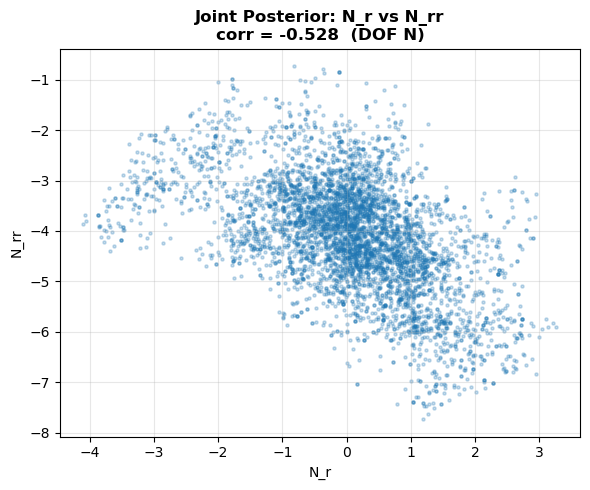

In [17]:
# =========================
import matplotlib as mpl
# USER HYPERPARAMETER
# =========================
ACTIVE_DOF = "N"   # "X","Y","Z","K","M","N"
# Reset to default light theme

# =========================
# DOF → parameter mapping
# =========================
name_map = {
    "X": ("X_dot_u", "X_u", "X_uu"),
    "Y": ("Y_dot_v", "Y_v", "Y_vv"),
    "Z": ("Z_dot_w", "Z_w", "Z_ww"),
    "K": ("K_dot_p", "K_p", "K_pp"),
    "M": ("M_dot_q", "M_q", "M_qq"),
    "N": ("N_dot_r", "N_r", "N_rr"),
}

if ACTIVE_DOF not in name_map:
    raise ValueError(f"ACTIVE_DOF must be one of {list(name_map.keys())}")

d_dot, d_lin, d_quad = name_map[ACTIVE_DOF]

# =========================
# Extract samples
# =========================
idx = {n: i for i, n in enumerate(param_names)}

x_dot = samples_tensor[:, idx[d_dot]].cpu().numpy()
x_lin = samples_tensor[:, idx[d_lin]].cpu().numpy()
x_quad = samples_tensor[:, idx[d_quad]].cpu().numpy()

# =========================
# Correlations
# =========================
c_lq = np.corrcoef(x_lin, x_quad)[0, 1]
c_la = np.corrcoef(x_lin, x_dot)[0, 1]
c_qa = np.corrcoef(x_quad, x_dot)[0, 1]

print(f"\n=== {ACTIVE_DOF}-DOF posterior coupling ===")
print(f"corr({d_lin}, {d_quad})   = {c_lq:+.3f}")
print(f"corr({d_lin}, {d_dot}) = {c_la:+.3f}")
print(f"corr({d_quad}, {d_dot}) = {c_qa:+.3f}")

# =========================
# Plot: linear vs quadratic
# =========================
plt.figure(figsize=(6, 5))
plt.scatter(x_lin, x_quad, s=5, alpha=0.25)
plt.xlabel(d_lin)
plt.ylabel(d_quad)
plt.title(
    f"Joint Posterior: {d_lin} vs {d_quad}\n"
    f"corr = {c_lq:+.3f}  (DOF {ACTIVE_DOF})",
    fontsize=12,
    fontweight="bold"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Loaded: /home/andrew/fossen_ml_pipeline/defender_parameter_estimator/hmc_outputs/hmc_yaw_samples_2.pt
samples_tensor shape: (5000, 23)

=== N-DOF posterior coupling ===
corr(N_r, N_rr) = -0.887
corr(N_r, N_dot_r)  = +0.519
corr(N_rr, N_dot_r) = -0.494


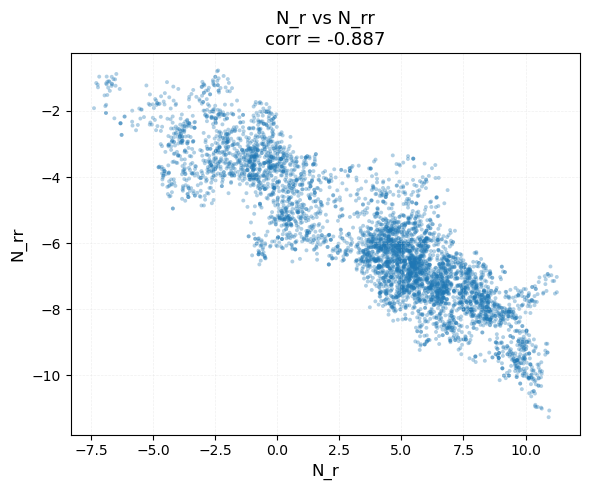

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================
# LOAD SAVED HMC OUTPUTS
# =========================
load_path = "/home/andrew/fossen_ml_pipeline/defender_parameter_estimator/hmc_outputs/hmc_yaw_samples_2.pt"

data = torch.load(load_path, map_location="cpu")
samples_tensor = data["samples"]        # (N, 26)
param_names    = data["param_names"]    # list[str], length 26

print(f"Loaded: {load_path}")
print(f"samples_tensor shape: {tuple(samples_tensor.shape)}")

# =========================
# USER HYPERPARAMETER
# =========================
ACTIVE_DOF = "N"   # "X","Y","Z","K","M","N"

# =========================
# DOF → parameter mapping
# =========================
name_map = {
    "X": ("X_dot_u", "X_u", "X_uu"),
    "Y": ("Y_dot_v", "Y_v", "Y_vv"),
    "Z": ("Z_dot_w", "Z_w", "Z_ww"),
    "K": ("K_dot_p", "K_p", "K_pp"),
    "M": ("M_dot_q", "M_q", "M_qq"),
    "N": ("N_dot_r", "N_r", "N_rr"),
}

if ACTIVE_DOF not in name_map:
    raise ValueError(f"ACTIVE_DOF must be one of {list(name_map.keys())}")

d_dot, d_lin, d_quad = name_map[ACTIVE_DOF]

# =========================
# Extract samples
# =========================
idx = {n: i for i, n in enumerate(param_names)}

missing = [p for p in (d_dot, d_lin, d_quad) if p not in idx]
if missing:
    raise KeyError(f"Missing parameters in saved file: {missing}")

x_dot  = samples_tensor[:, idx[d_dot]].numpy()
x_lin  = samples_tensor[:, idx[d_lin]].numpy()
x_quad = samples_tensor[:, idx[d_quad]].numpy()

# =========================
# Correlations
# =========================
c_lq = np.corrcoef(x_lin, x_quad)[0, 1]
c_la = np.corrcoef(x_lin, x_dot)[0, 1]
c_qa = np.corrcoef(x_quad, x_dot)[0, 1]

print(f"\n=== {ACTIVE_DOF}-DOF posterior coupling ===")
print(f"corr({d_lin}, {d_quad}) = {c_lq:+.3f}")
print(f"corr({d_lin}, {d_dot})  = {c_la:+.3f}")
print(f"corr({d_quad}, {d_dot}) = {c_qa:+.3f}")

# =========================
# Plot: linear vs quadratic
# =========================


# --- FORCE CLEAN "DEFAULT" MATPLOTLIB LOOK ---
plt.close("all")                       # close any existing themed figs
plt.style.use("default")               # reset style
mpl.rcParams.update(mpl.rcParamsDefault)

# hard-force white backgrounds + black text (themes sometimes override these)
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.facecolor"]   = "white"
mpl.rcParams["savefig.facecolor"] = "white"
mpl.rcParams["text.color"]       = "black"
mpl.rcParams["axes.labelcolor"]  = "black"
mpl.rcParams["xtick.color"]      = "black"
mpl.rcParams["ytick.color"]      = "black"
mpl.rcParams["axes.edgecolor"]   = "black"
mpl.rcParams["grid.color"]       = "0.85"
plt.figure(figsize=(6, 5))

plt.scatter(
    x_lin,
    x_quad,
    s=8,
    alpha=0.35,
    edgecolors='none'
)

plt.xlabel(d_lin, fontsize=12)
plt.ylabel(d_quad, fontsize=12)

plt.title(
    f"{d_lin} vs {d_quad}\n"
    f"corr = {c_lq:+.3f}",
    fontsize=13
)

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.show()



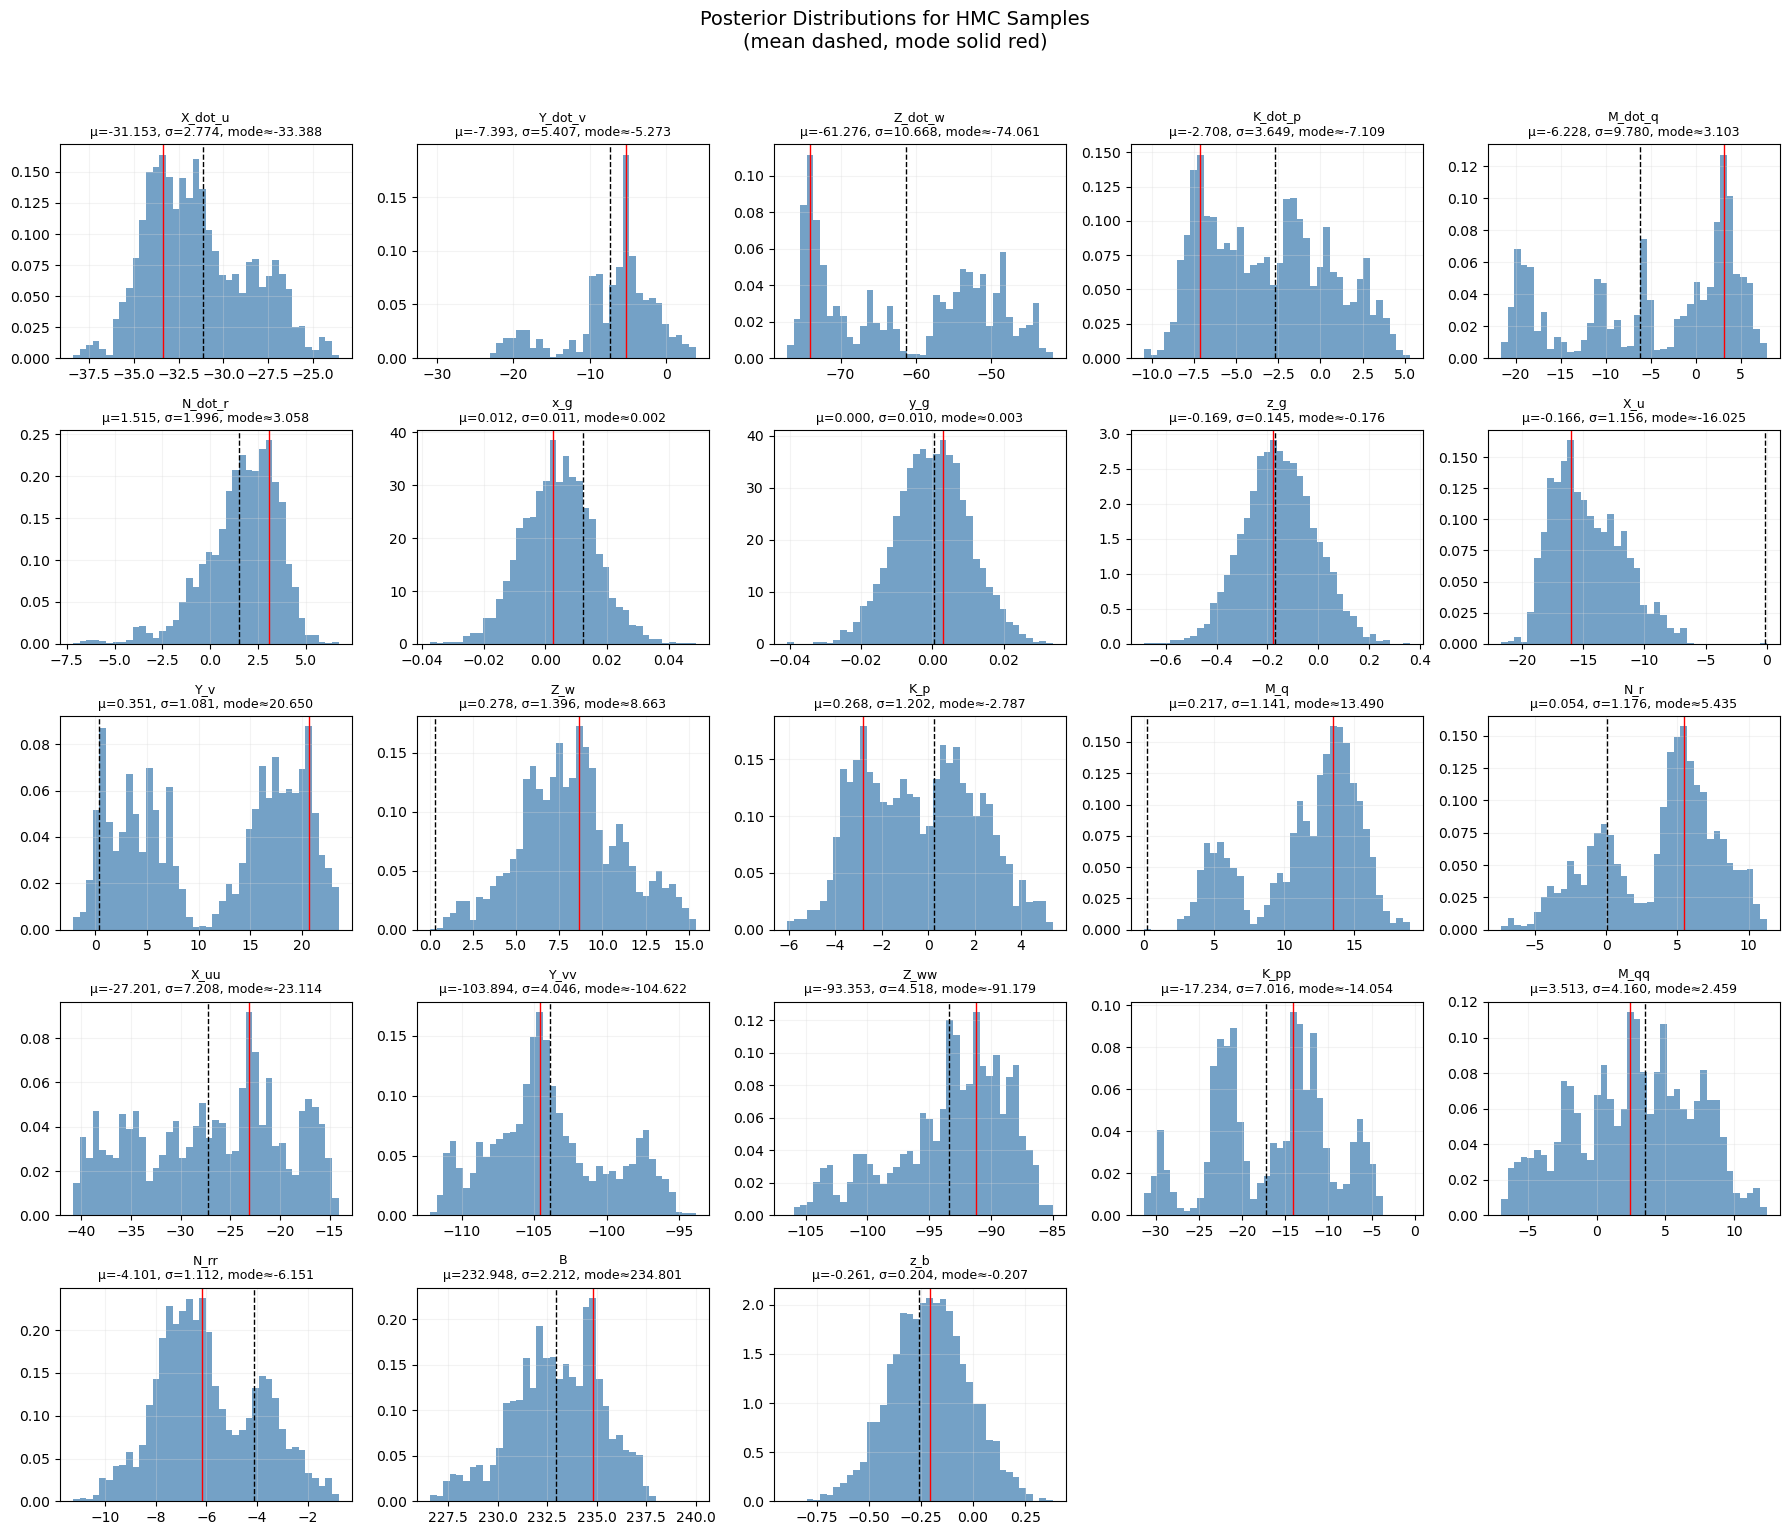

In [19]:
# ──────────────────────────────────────────────────────────────────────────────
# 5) Plot posterior histograms for each parameter (mean + mode)
# ──────────────────────────────────────────────────────────────────────────────

num_params = samples_tensor.shape[1]
ncols = 5
nrows = math.ceil(num_params / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3 * nrows))
axes = axes.flatten()

for i, name in enumerate(param_names):
    ax = axes[i]
    data = samples_tensor[:, i].cpu().numpy()

    # Histogram (get counts + bin edges to compute mode)
    counts, bins, _ = ax.hist(data, bins=40, density=True, color='steelblue', alpha=0.75)

    # Mean and Std from earlier
    m = post_mean[i].item()
    s = post_std[i].item()

    # Mode = midpoint of highest histogram bin
    mode_idx = np.argmax(counts)
    mode_val = 0.5 * (bins[mode_idx] + bins[mode_idx + 1])

    # Draw vertical lines
    ax.axvline(m, color='k', linestyle='--', linewidth=1, label='mean')
    ax.axvline(mode_val, color='r', linestyle='-', linewidth=1, label='mode')

    # Title with μ, σ, and mode
    ax.set_title(f"{name}\nμ={m:.3f}, σ={s:.3f}, mode≈{mode_val:.3f}", fontsize=9)
    ax.grid(alpha=0.3)

# Remove any unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Posterior Distributions for HMC Samples\n(mean dashed, mode solid red)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

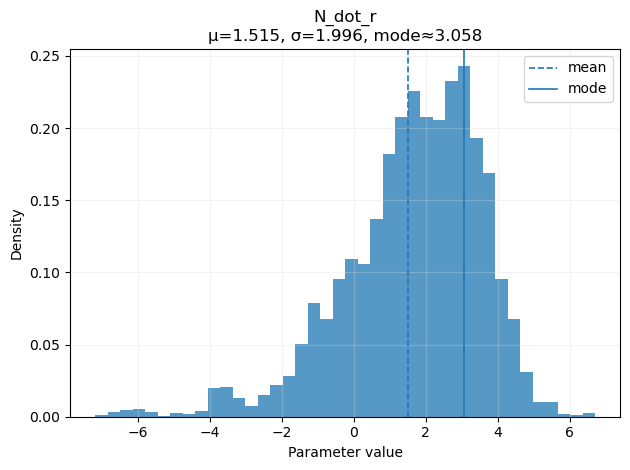

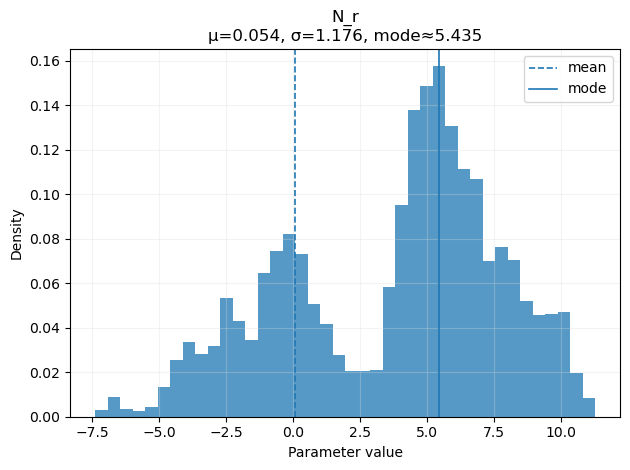

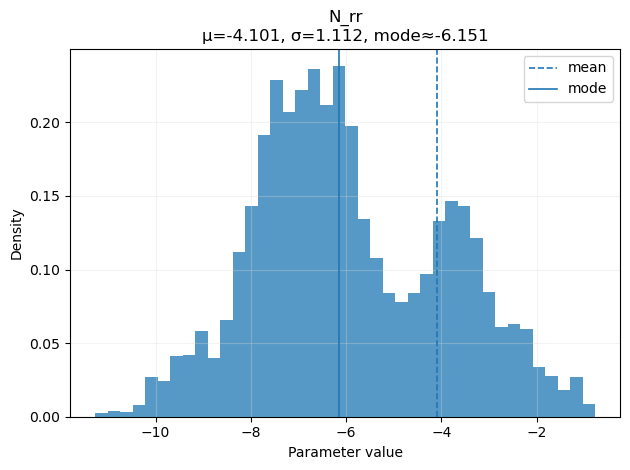

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Map DOF group -> list of parameter names to plot
# ------------------------------------------------------------
PARAM_GROUPS = {
    "X": ["X_dot_u", "X_u", "X_uu"],
    "Y": ["Y_dot_v", "Y_v", "Y_vv"],
    "Z": ["Z_dot_w", "Z_w", "Z_ww"],
    "K": ["K_dot_p", "K_p", "K_pp"],
    "M": ["M_dot_q", "M_q", "M_qq"],
    "N": ["N_dot_r", "N_r", "N_rr"],
    # Optional extras (not hydrodynamic coeffs but you might want them)
    "inertia": ["I_xx", "I_yy", "I_zz"],
    "cg": ["x_g", "y_g", "z_g"],
    "buoyancy": ["B", "z_b"],
}

# ------------------------------------------------------------
# 2) Helper: plot one parameter histogram with mean/std/mode
# ------------------------------------------------------------
def plot_param_hist(name: str, samples_tensor, param_names, post_mean, post_std, bins=40):
    if name not in param_names:
        print(f"[skip] {name} not found in param_names")
        return

    i = param_names.index(name)
    data = samples_tensor[:, i].detach().cpu().numpy()

    counts, edges, _ = plt.hist(data, bins=bins, density=True, alpha=0.75)
    m = float(post_mean[i].detach().cpu())
    s = float(post_std[i].detach().cpu())

    # mode from histogram bin with max count
    k = int(np.argmax(counts))
    mode_val = 0.5 * (edges[k] + edges[k + 1])

    plt.axvline(m, linestyle="--", linewidth=1.2, label="mean")
    plt.axvline(mode_val, linestyle="-", linewidth=1.2, label="mode")

    plt.title(f"{name}\nμ={m:.3f}, σ={s:.3f}, mode≈{mode_val:.3f}", fontsize=12)
    plt.xlabel("Parameter value")
    plt.ylabel("Density")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 3) Choose a DOF group and plot all associated coefficients
# ------------------------------------------------------------
target_group = "N"  # <-- set to "X","Y","Z","K","M","N", etc.

names_to_plot = PARAM_GROUPS.get(target_group, None)
if names_to_plot is None:
    raise ValueError(f"Unknown target_group='{target_group}'. Valid keys: {list(PARAM_GROUPS.keys())}")

for pname in names_to_plot:
    plot_param_hist(
        pname,
        samples_tensor=samples_tensor,
        param_names=param_names,
        post_mean=post_mean,
        post_std=post_std,
        bins=40,
    )
